In [34]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import optuna

# Import data

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


# Visualize the data

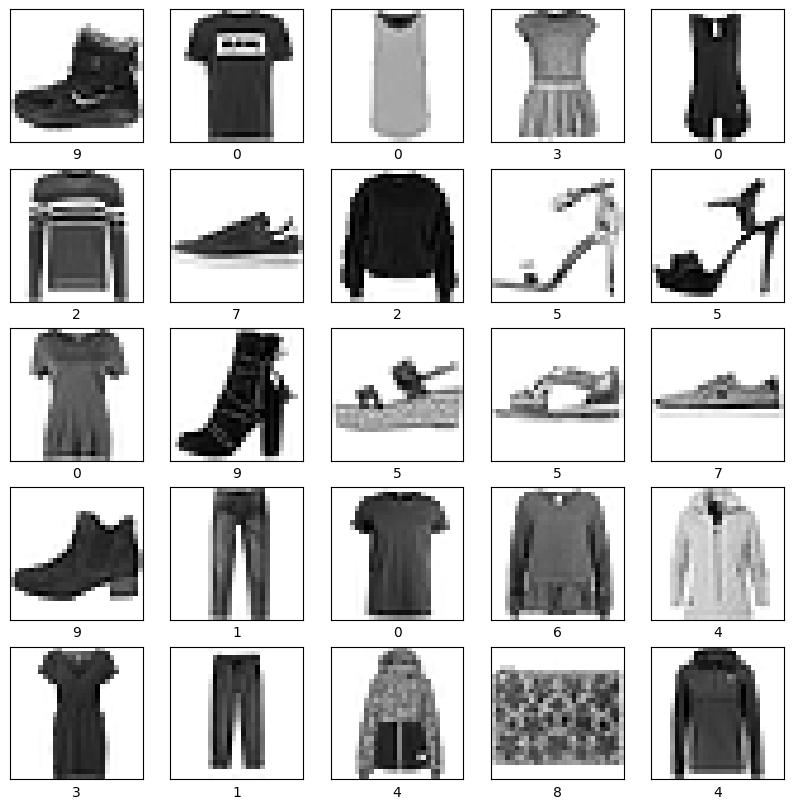

In [3]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

# Preparing data for CNN

In [4]:
#normalize data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = X_train[..., np.newaxis]  # add channel dimension → (60000, 28, 28, 1) AKA 60,000 training samples, 28x28 dimensions, 1 channel
X_test = X_test[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


# Baseline CNN model

In [5]:
# define the model
cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for clothing types
])

In [6]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train,                                      # image data with spatial structure
    y_train,                                      # labels 
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8549 - loss: 0.4099 - val_accuracy: 0.8848 - val_loss: 0.3264
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9008 - loss: 0.2782 - val_accuracy: 0.9043 - val_loss: 0.2722
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9144 - loss: 0.2351 - val_accuracy: 0.8965 - val_loss: 0.2910
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9249 - loss: 0.2054 - val_accuracy: 0.9075 - val_loss: 0.2485
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9346 - loss: 0.1774 - val_accuracy: 0.9123 - val_loss: 0.2437


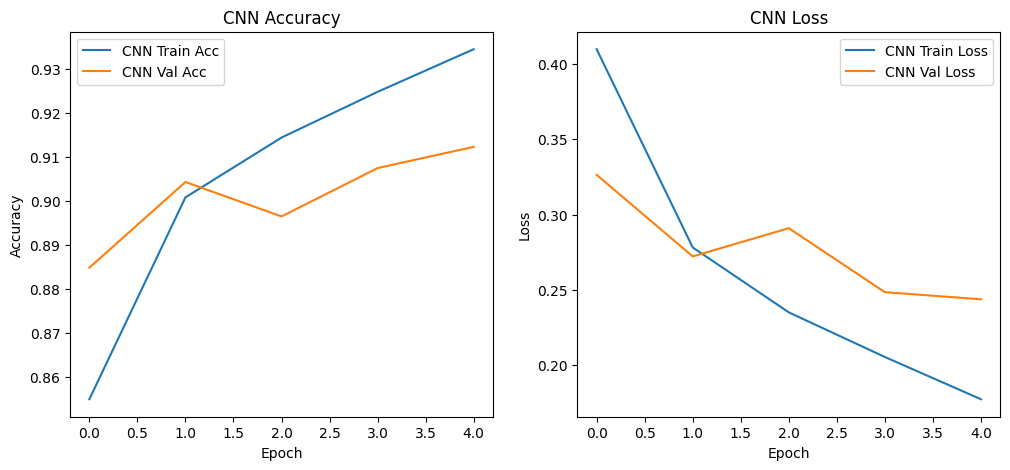

In [7]:
# plot training history for baseline CNN model (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [8]:
# Evaluate the baseline CNN model on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test)      # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - accuracy: 0.9092 - loss: 0.2581
CNN Test Accuracy: 0.9092000126838684


# Experiment 1: Build a deeper CNN model (extra convolution + pooling layer)

In [10]:
# define the model
cnn_model_deeper = models.Sequential([
    layers.Input(shape=(28,28,1)),                 # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),   # apply 32 filters to detect low-level patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                    # reduce spatial size: 28x28 → 13x13
    layers.Conv2D(64, (3,3), activation="relu"),   # apply 64 filters to detect higher-level patterns (shapes, textures)
    layers.MaxPooling2D((2,2)),                    # reduce spatial size: 13x13 → 5x5
    layers.Flatten(),                              # convert feature maps into a vector
    layers.Dense(64, activation="relu"),           # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),        # output probabilities for clothing types
])

In [11]:
# compile the model
cnn_model_deeper.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history_deeper = cnn_model_deeper.fit(
    X_train,                                      # image data with spatial structure
    y_train,                                      # labels 
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8310 - loss: 0.4722 - val_accuracy: 0.8712 - val_loss: 0.3515
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8841 - loss: 0.3178 - val_accuracy: 0.8880 - val_loss: 0.3040
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9004 - loss: 0.2702 - val_accuracy: 0.8963 - val_loss: 0.2887
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9116 - loss: 0.2409 - val_accuracy: 0.8888 - val_loss: 0.3054
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9200 - loss: 0.2148 - val_accuracy: 0.9055 - val_loss: 0.2535


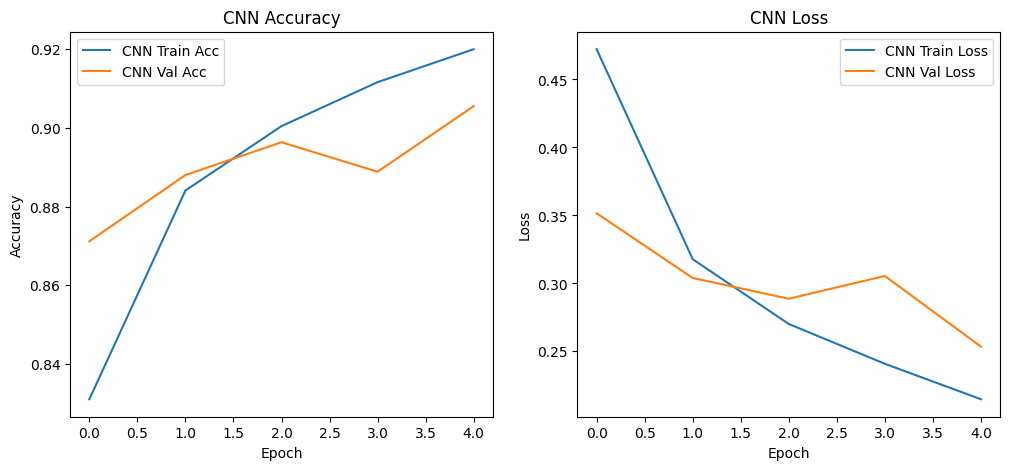

In [ ]:
# plot training history for deeper CNN model (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history_deeper.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history_deeper.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_deeper.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history_deeper.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the deeper CNN model on test data
cnn_loss, cnn_acc = cnn_model_deeper.evaluate(X_test, y_test)      # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9033 - loss: 0.2662
CNN Test Accuracy: 0.9032999873161316


# Experiment 2: Average pooling instead of max pooling

In [15]:
# define the model
cnn_model_avg_pooling = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.AveragePooling2D((2,2)),               # reduce spatial size with average pooling (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for clothing types
])

In [16]:
# compile the model
cnn_model_avg_pooling.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history_avg_pooling = cnn_model_avg_pooling.fit(
    X_train,                                      # image data with spatial structure
    y_train,                                      # labels 
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8414 - loss: 0.4490 - val_accuracy: 0.8818 - val_loss: 0.3307
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8893 - loss: 0.3081 - val_accuracy: 0.8960 - val_loss: 0.2904
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9031 - loss: 0.2658 - val_accuracy: 0.8988 - val_loss: 0.2853
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9126 - loss: 0.2373 - val_accuracy: 0.9060 - val_loss: 0.2575
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9204 - loss: 0.2150 - val_accuracy: 0.9080 - val_loss: 0.2639


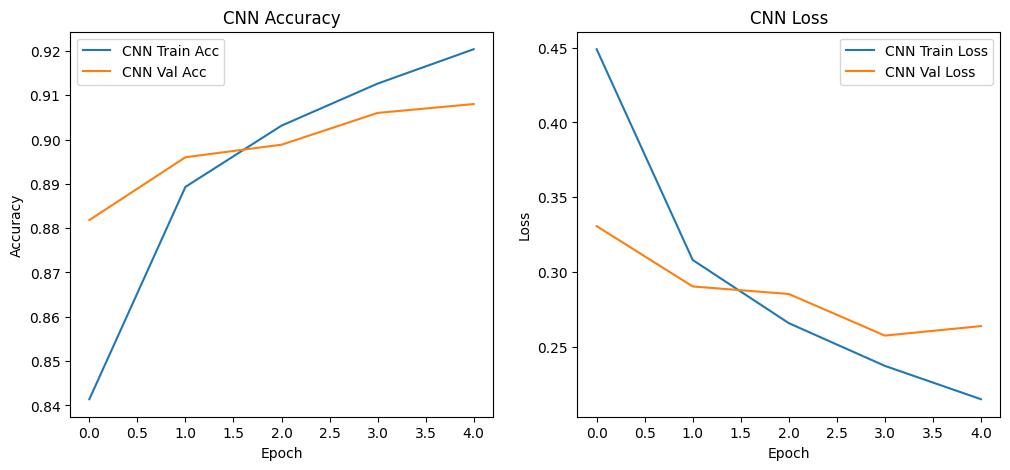

In [ ]:
# plot training history for average pooling CNN model (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history_avg_pooling.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history_avg_pooling.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_avg_pooling.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history_avg_pooling.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [18]:
# Evaluate the average pooling CNN model on test data
cnn_loss, cnn_acc = cnn_model_avg_pooling.evaluate(X_test, y_test)      # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.9011 - loss: 0.2745
CNN Test Accuracy: 0.9010999798774719


# Experiment 3: Average pooling and deeper CNN

In [19]:
# define the model
cnn_model_deeper = models.Sequential([
    layers.Input(shape=(28,28,1)),                 # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),   # apply 32 filters to detect low-level patterns (edges, curves)
    layers.AvgPool2D((2,2)),                    # reduce spatial size: 28x28 → 13x13
    layers.Conv2D(64, (3,3), activation="relu"),   # apply 64 filters to detect higher-level patterns (shapes, textures)
    layers.AvgPool2D((2,2)),                    # reduce spatial size: 13x13 → 5x5
    layers.Flatten(),                              # convert feature maps into a vector
    layers.Dense(64, activation="relu"),           # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),        # output probabilities for clothing types
])

In [20]:
# compile the model
cnn_model_deeper.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history_deeper = cnn_model_deeper.fit(
    X_train,                                      # image data with spatial structure
    y_train,                                      # labels 
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8053 - loss: 0.5379 - val_accuracy: 0.8647 - val_loss: 0.3819
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8692 - loss: 0.3627 - val_accuracy: 0.8727 - val_loss: 0.3460
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8866 - loss: 0.3113 - val_accuracy: 0.8792 - val_loss: 0.3213
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8968 - loss: 0.2798 - val_accuracy: 0.8833 - val_loss: 0.3066
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9054 - loss: 0.2560 - val_accuracy: 0.8977 - val_loss: 0.2865


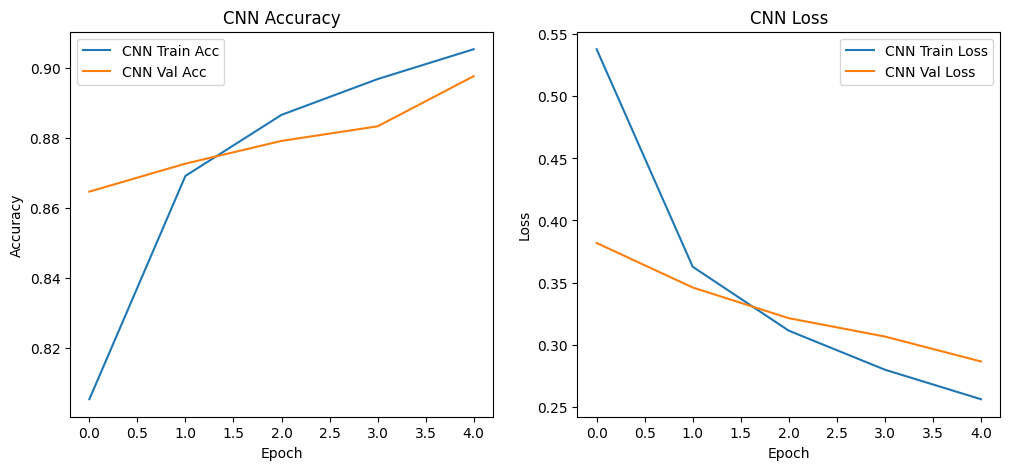

In [21]:
# plot training history for deeper CNN model (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history_deeper.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history_deeper.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_deeper.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history_deeper.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# Evaluate the deeper CNN model on test data
cnn_loss, cnn_acc = cnn_model_deeper.evaluate(X_test, y_test)      # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8906 - loss: 0.3048
CNN Test Accuracy: 0.8906000256538391


# Experiment 4: More epochs

In [23]:
# define the model
cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for clothing types
])

In [24]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train,                                      # image data with spatial structure
    y_train,                                      # labels 
    epochs=10,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8464 - loss: 0.4334 - val_accuracy: 0.8812 - val_loss: 0.3443
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8949 - loss: 0.2949 - val_accuracy: 0.8977 - val_loss: 0.2841
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9086 - loss: 0.2538 - val_accuracy: 0.8963 - val_loss: 0.2899
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9190 - loss: 0.2226 - val_accuracy: 0.9050 - val_loss: 0.2681
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9278 - loss: 0.1977 - val_accuracy: 0.9073 - val_loss: 0.2574
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9365 - loss: 0.1743 - val_accuracy: 0.9132 - val_loss: 0.2549
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9428 - loss: 0.1550 - val_accuracy: 0.9138 - val_loss: 0.2589
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9497 - loss: 0.1376 - 

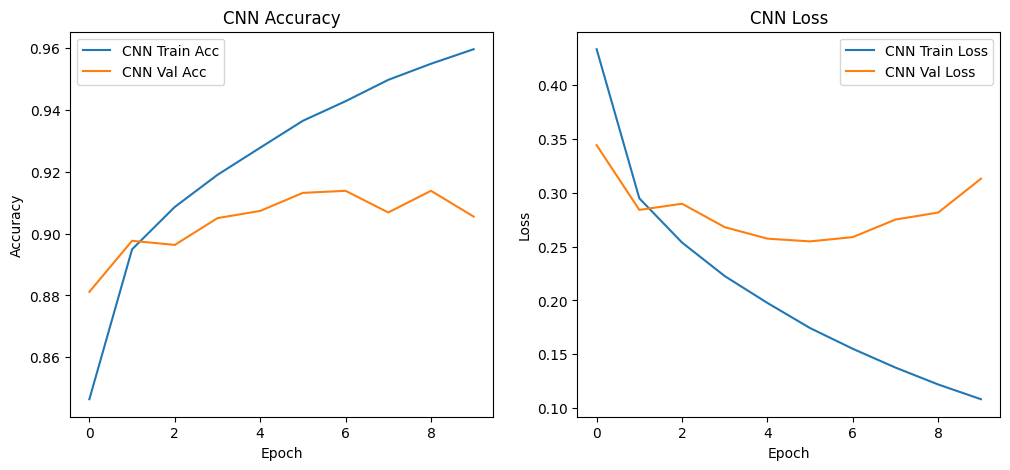

In [25]:
# plot training history for CNN model (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [26]:
# Evaluate the baseline CNN model on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test)      # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.9055 - loss: 0.3111
CNN Test Accuracy: 0.9054999947547913


# Experiment 5: More epochs and regularization

In [51]:
# define the model with regularization
cnn_model_reg = models.Sequential([
    layers.Input(shape=(28,28,1)),                          
    layers.Conv2D(32, (3,3), activation="relu"),            
    layers.MaxPooling2D((2,2)),                             
    layers.Dropout(0.25),                                   # dropout after pooling
    layers.Flatten(),                                       
    layers.Dense(64, activation="relu"),                    
    layers.Dense(10, activation="softmax"),                 
])

In [52]:
# compile the model
cnn_model_reg.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# train the model
cnn_reg_history = cnn_model_reg.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8473 - loss: 0.4307 - val_accuracy: 0.8842 - val_loss: 0.3191
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8934 - loss: 0.2968 - val_accuracy: 0.8993 - val_loss: 0.2708
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9054 - loss: 0.2609 - val_accuracy: 0.9070 - val_loss: 0.2592
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9135 - loss: 0.2322 - val_accuracy: 0.9082 - val_loss: 0.2495
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9222 - loss: 0.2103 - val_accuracy: 0.9055 - val_loss: 0.2699
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9291 - loss: 0.1929 - val_accuracy: 0.9087 - val_loss: 0.2500
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9346 - loss: 0.1779 - val_accuracy: 0.9075 - val_loss: 0.2614
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9383 - loss: 0.1629 - 

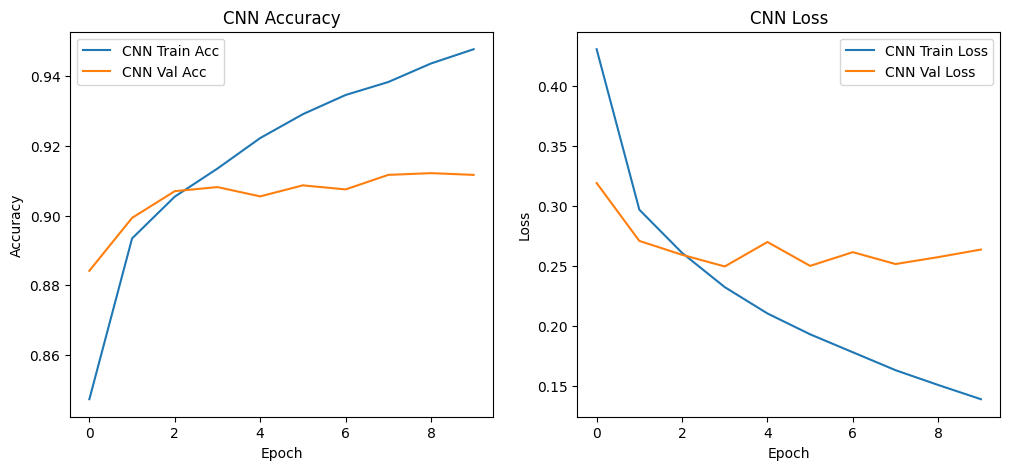

In [55]:
# plot training history for CNN model (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_reg_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_reg_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_reg_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_reg_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [56]:
# Evaluate the baseline CNN model on test data
cnn_loss, cnn_acc = cnn_model_reg.evaluate(X_test, y_test)      # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - accuracy: 0.9088 - loss: 0.2745
CNN Test Accuracy: 0.9088000059127808


# Experiment 6: More epochs and heavier regularization

In [61]:
# define the model with regularization
cnn_model_reg = models.Sequential([
    layers.Input(shape=(28,28,1)),                          
    layers.Conv2D(32, (3,3), activation="relu"),            
    layers.MaxPooling2D((2,2)),                             
    layers.Dropout(0.5),                                   # dropout after pooling
    layers.Flatten(),                                       
    layers.Dense(64, activation="relu"),                    
    layers.Dense(10, activation="softmax"),                 
])

In [62]:
# compile the model
cnn_model_reg.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# train the model
cnn_reg_history = cnn_model_reg.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8400 - loss: 0.4514 - val_accuracy: 0.8800 - val_loss: 0.3290
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8835 - loss: 0.3236 - val_accuracy: 0.8993 - val_loss: 0.2861
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8948 - loss: 0.2850 - val_accuracy: 0.8995 - val_loss: 0.2739
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9029 - loss: 0.2607 - val_accuracy: 0.9072 - val_loss: 0.2496
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9086 - loss: 0.2442 - val_accuracy: 0.9012 - val_loss: 0.2656
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9167 - loss: 0.2249 - val_accuracy: 0.9138 - val_loss: 0.2454
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9210 - loss: 0.2127 - val_accuracy: 0.9110 - val_loss: 0.2471
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9232 - loss: 0.2038 - 

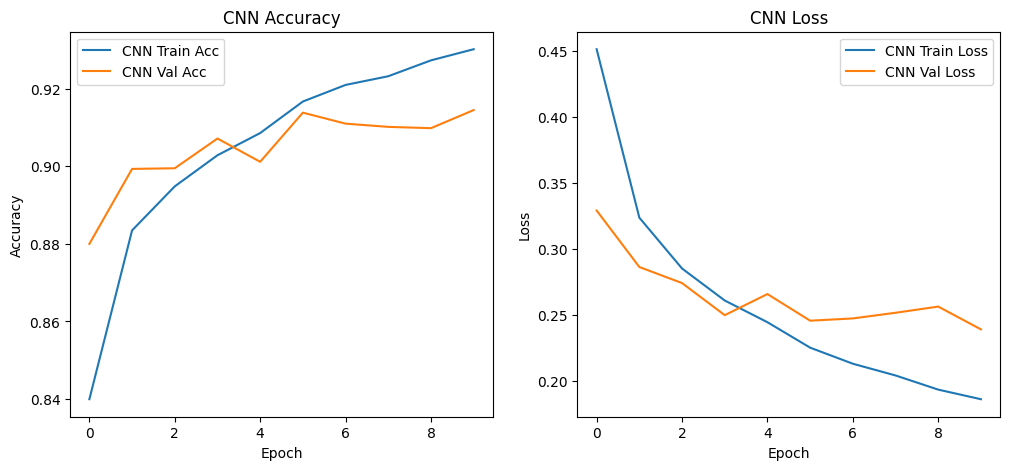

In [63]:
# plot training history for CNN model (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_reg_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_reg_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_reg_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_reg_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [64]:
# Evaluate the baseline CNN model on test data
cnn_loss, cnn_acc = cnn_model_reg.evaluate(X_test, y_test)      # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - accuracy: 0.9144 - loss: 0.2484
CNN Test Accuracy: 0.9143999814987183


# Experiment 7: Adding data augmentation during training

In [27]:
# define data augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1)
])

# define CNN model with data augmentation
cnn_aug_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),          

    data_augmentation,                          # apply augmentation during training only

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")     
])

In [ ]:
# compile
cnn_aug_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",   
    metrics=["accuracy"]
)

# train
cnn_aug_history = cnn_aug_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=5
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7578 - loss: 0.6558 - val_accuracy: 0.8095 - val_loss: 0.5231
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8221 - loss: 0.4825 - val_accuracy: 0.8483 - val_loss: 0.4179
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8385 - loss: 0.4372 - val_accuracy: 0.8602 - val_loss: 0.3799
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8501 - loss: 0.4088 - val_accuracy: 0.8597 - val_loss: 0.4055
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8553 - loss: 0.3930 - val_accuracy: 0.8693 - val_loss: 0.3653


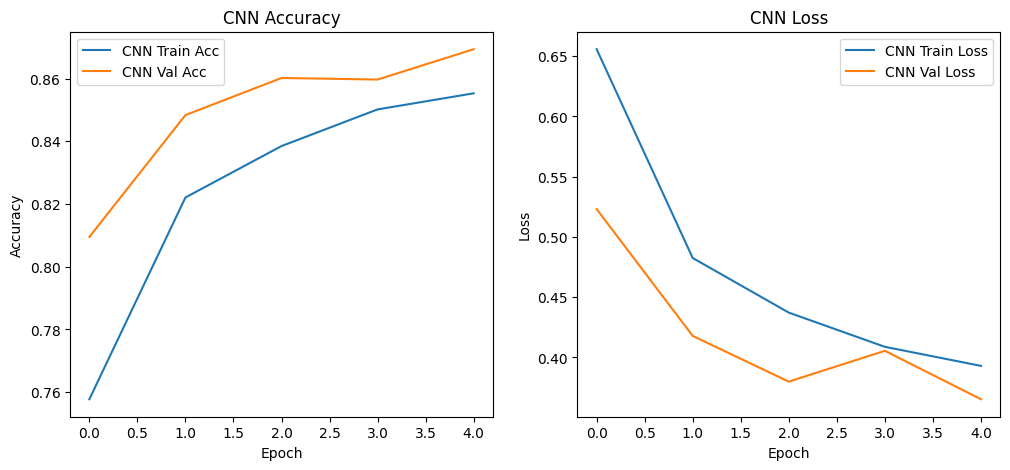

In [32]:
# plot training history for CNN model (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_aug_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_aug_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [33]:
# Evaluate the baseline CNN model on test data
cnn_loss, cnn_acc = cnn_aug_model.evaluate(X_test, y_test)      # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.8717 - loss: 0.3822
CNN Test Accuracy: 0.8716999888420105


# Tuned CNN model with Optuna

Note that I had to keep the number of trials small, as this code was taking a very long time to run.

In [ ]:
def objective(trial):
    pooling_type = trial.suggest_categorical("pooling_type", ["max", "average"])  # pooling experiment
    use_augmentation = trial.suggest_categorical("use_augmentation", [True, False])  # augmentation experiment

    # tuned hyperparameters 
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])

    inputs = keras.Input(shape=(28, 28, 1))
    x = inputs

    # optional augmentation
    if use_augmentation:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.05)(x)
        x = layers.RandomZoom(0.05)(x)
        x = layers.RandomTranslation(0.05, 0.05)(x)
        x = layers.RandomContrast(0.1)(x)

    # single conv block
    n_filters = trial.suggest_categorical("n_filters", [32, 64])
    kernel_size = trial.suggest_int("kernel_size", 3, 5, step=2)
    x = layers.Conv2D(n_filters, (kernel_size, kernel_size), activation="relu", padding="same")(x)

    if pooling_type == "max":
        x = layers.MaxPooling2D((2, 2))(x)
    else:
        x = layers.AveragePooling2D((2, 2))(x)

    dropout_rate = trial.suggest_float("dropout", 0.0, 0.5, step=0.1)
    x = layers.Dropout(dropout_rate)(x)

    # dense head
    x = layers.Flatten()(x)
    n_dense_units = trial.suggest_categorical("n_dense_units", [64, 128])
    x = layers.Dense(n_dense_units, activation="relu")(x)
    dense_dropout = trial.suggest_float("dense_dropout", 0.0, 0.5, step=0.1)
    x = layers.Dropout(dense_dropout)(x)

    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        validation_split=0.2,
        batch_size=batch_size,
        verbose=1
    )

    best_epoch = np.argmax(history.history["val_accuracy"])
    return history.history["val_accuracy"][best_epoch]


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best validation accuracy:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-28 00:23:42,261] A new study created in memory with name: no-name-9f95af01-8f95-49d4-9649-26fad50f26b6


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7724 - loss: 0.6413 - val_accuracy: 0.8661 - val_loss: 0.3735
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8545 - loss: 0.4157 - val_accuracy: 0.8854 - val_loss: 0.3171
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8680 - loss: 0.3705 - val_accuracy: 0.8911 - val_loss: 0.2959
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8780 - loss: 0.3442 - val_accuracy: 0.8965 - val_loss: 0.2878
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8851 - loss: 0.3224 - val_accuracy: 0.8984 - val_loss: 0.2825
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8915 - loss: 0.3078 - val_accuracy: 0.9049 - val_loss: 0.2673
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8934 - loss: 0.2942 - val_accuracy: 0.9049 - val_loss: 0.2618
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8965 - loss: 0.2822 - val_accuracy: 0.

[I 2026-05-28 00:24:28,391] Trial 0 finished with value: 0.9100000262260437 and parameters: {'pooling_type': 'average', 'use_augmentation': False, 'learning_rate': 0.0009236433575322304, 'batch_size': 64, 'n_filters': 64, 'kernel_size': 3, 'dropout': 0.0, 'n_dense_units': 64, 'dense_dropout': 0.4}. Best is trial 0 with value: 0.9100000262260437.


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7916 - loss: 0.5925 - val_accuracy: 0.8631 - val_loss: 0.3719
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8615 - loss: 0.3976 - val_accuracy: 0.8900 - val_loss: 0.3132
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8783 - loss: 0.3454 - val_accuracy: 0.8948 - val_loss: 0.2884
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8870 - loss: 0.3175 - val_accuracy: 0.9012 - val_loss: 0.2738
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8935 - loss: 0.2945 - val_accuracy: 0.9016 - val_loss: 0.2774
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8990 - loss: 0.2791 - val_accuracy: 0.9041 - val_loss: 0.2648
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9047 - loss: 0.2610 - val_accuracy: 0.9043 - val_loss: 0.2566
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9095 - loss: 0.2461 - val_accuracy: 0.

[I 2026-05-28 00:25:02,076] Trial 1 finished with value: 0.9103333353996277 and parameters: {'pooling_type': 'max', 'use_augmentation': False, 'learning_rate': 0.0012248953216338978, 'batch_size': 64, 'n_filters': 32, 'kernel_size': 3, 'dropout': 0.0, 'n_dense_units': 64, 'dense_dropout': 0.4}. Best is trial 1 with value: 0.9103333353996277.


...

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7062 - loss: 0.8600 - val_accuracy: 0.8169 - val_loss: 0.5125
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7954 - loss: 0.5870 - val_accuracy: 0.8407 - val_loss: 0.4370
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8129 - loss: 0.5318 - val_accuracy: 0.8510 - val_loss: 0.4131
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8282 - loss: 0.4918 - val_accuracy: 0.8609 - val_loss: 0.3829
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8362 - loss: 0.4687 - val_accuracy: 0.8679 - val_loss: 0.3688
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8440 - loss: 0.4454 - val_accuracy: 0.8713 - val_loss: 0.3564
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8504 - loss: 0.4264 - val_accuracy: 0.8752 - val_loss: 0.3494
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8554 - loss: 0.4143 - 

[I 2026-05-28 00:33:49,878] Trial 8 finished with value: 0.8805833458900452 and parameters: {'pooling_type': 'average', 'use_augmentation': False, 'learning_rate': 0.0001407211048064761, 'batch_size': 32, 'n_filters': 32, 'kernel_size': 3, 'dropout': 0.2, 'n_dense_units': 64, 'dense_dropout': 0.5}. Best is trial 4 with value: 0.9180833101272583.


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7415 - loss: 0.6954 - val_accuracy: 0.8322 - val_loss: 0.4727
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7874 - loss: 0.5725 - val_accuracy: 0.8363 - val_loss: 0.4457
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7974 - loss: 0.5434 - val_accuracy: 0.8503 - val_loss: 0.4319
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8026 - loss: 0.5272 - val_accuracy: 0.8521 - val_loss: 0.4449
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8084 - loss: 0.5130 - val_accuracy: 0.8531 - val_loss: 0.4284
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8097 - loss: 0.5057 - val_accuracy: 0.8449 - val_loss: 0.4537
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8142 - loss: 0.4990 - val_accuracy: 0.8473 - val_loss: 0.4464
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8161 - loss: 0.4939

[I 2026-05-28 00:35:24,636] Trial 9 finished with value: 0.8530833125114441 and parameters: {'pooling_type': 'max', 'use_augmentation': True, 'learning_rate': 0.004097485574833884, 'batch_size': 32, 'n_filters': 64, 'kernel_size': 5, 'dropout': 0.30000000000000004, 'n_dense_units': 64, 'dense_dropout': 0.30000000000000004}. Best is trial 4 with value: 0.9180833101272583.


Best validation accuracy: 0.9180833101272583
Best parameters: {'pooling_type': 'average', 'use_augmentation': False, 'learning_rate': 0.0008032752036027432, 'batch_size': 32, 'n_filters': 32, 'kernel_size': 5, 'dropout': 0.30000000000000004, 'n_dense_units': 128, 'dense_dropout': 0.30000000000000004}


In [67]:
# Building the best model from Optuna results
best_params = study.best_params
pooling_type = best_params["pooling_type"]
use_augmentation = best_params["use_augmentation"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]

inputs = keras.Input(shape=(28, 28, 1))
x = inputs

# optional augmentation
if use_augmentation:
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.05)(x)
    x = layers.RandomTranslation(0.05, 0.05)(x)
    x = layers.RandomContrast(0.1)(x)

# single conv block
x = layers.Conv2D(best_params["n_filters"], (best_params["kernel_size"], best_params["kernel_size"]), activation="relu", padding="same")(x)

if pooling_type == "max":
    x = layers.MaxPooling2D((2, 2))(x)
else:
    x = layers.AveragePooling2D((2, 2))(x)

x = layers.Dropout(best_params["dropout"])(x)

# dense head
x = layers.Flatten()(x)
x = layers.Dense(best_params["n_dense_units"], activation="relu")(x)
x = layers.Dropout(best_params["dense_dropout"])(x)

outputs = layers.Dense(10, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = best_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=10,
    validation_split=0.2,
    verbose=1,
)

scores = best_model.evaluate(X_test, y_test, verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8239 - loss: 0.4935 - val_accuracy: 0.8748 - val_loss: 0.3499
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8746 - loss: 0.3478 - val_accuracy: 0.8824 - val_loss: 0.3207
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8875 - loss: 0.3068 - val_accuracy: 0.8993 - val_loss: 0.2793
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8960 - loss: 0.2843 - val_accuracy: 0.9000 - val_loss: 0.2724
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9036 - loss: 0.2618 - val_accuracy: 0.9049 - val_loss: 0.2612
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9094 - loss: 0.2447 - val_accuracy: 0.9070 - val_loss: 0.2566
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9138 - loss: 0.2322 - val_accuracy: 0.9105 - val_loss: 0.2501
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9188 - loss: 0.2194 - 

In [69]:
# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1) 

print("\nBest Model Test Set Evaluation:")
print(f"Test Accuracy: {scores[1]:.4f}")
print(f"Test Loss: {scores[0]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step

Best Model Test Set Evaluation:
Test Accuracy: 0.9081
Test Loss: 0.2626


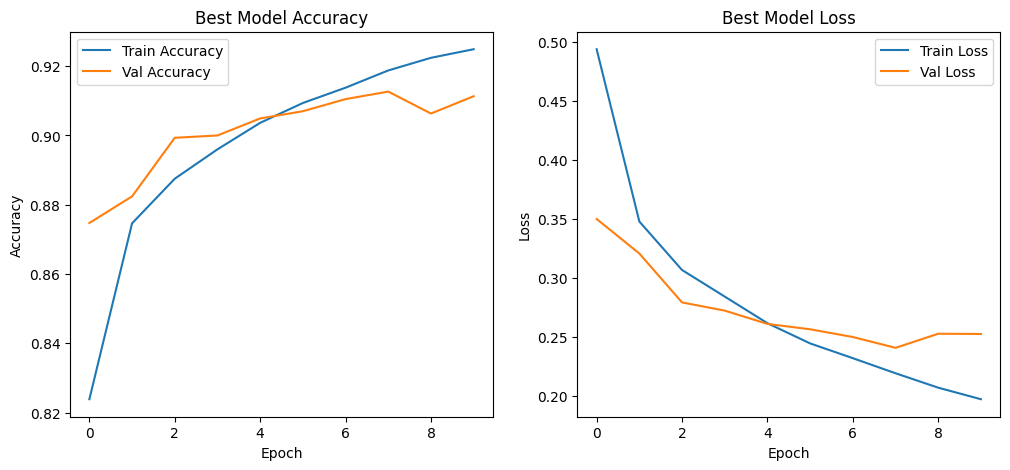

In [70]:
# Plot training history for best model (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Best Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Best Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Analysis

**Individual experiments**

I am surprised that so many of my individual experiments did not result in a larger test accuracy score compared to the baseline model's test accuracy score of 0.909. The only experiment that resulted in a higher score (and my best model by far) is the one using more epochs (10 instead of 5) and a heavy dropout rate (0.5), with a test accuracy of 0.914. I noticed that adding epochs was resulting in a closer test accuracy score to the baseline model, but given the training and validation loss/accuracy over epochs curves in experiment 4, the model was clearly overfitting on the training data. So, I added regularization (dropout = 0.25) in experiment 5 along with adding more epochs to test if regularization helps with the overfitting (it did). Still, the training/validation loss and accuracy curves showed signs of the model overfitting the training data, so I added an even heavier dropout rate of 0.5 to experiment 6. As seen in the training/validation loss and accuracy curves from this experiment, the model performed much better at preventing overfitting (the training and validation curves are close together in both plots). So, more epochs can result in better performing models, but the clear tradeoff is the risk of overfitting. However, regularization methods like dropout can handle that issue. Interestingly, my first experiment where I added an extra layer to the CNN did not result in a higher test accuracy score than the baseline model. This indicates that richer insights likely do not need to be derived with an additional modeling layer. The second experiment using average instead of max pooling also did not result in a higher test accuracy score compared to the baseline model. However, the training and validation curves seem much closer than the same curves in the baseline model, likely indicating that the experimented model does not overfit as much as the baseline model. There is definitely a tradeoff with using average instead of max pooling though. Max pooling clearly can pull more sharper, obvious, and potentially richer insights while average pooling can result in the loss of information due to averaging out results/outputs. Lastly, I was a bit surprised about experiment 7's results as well (data augmentation). This experiment resulted in the lowest test accuracy score of 0.872. This indicates to me that for more standardized images like in the Fashion MNIST dataset, augmentation can complicate or add more noise to the model without adding information. Data augmentation seems to be more helpful for "messy" or unstandardized data like the cats and dogs dataset from the in-class assignment.

**Optuna model**

I didn't find Optuna to be very helpful in identifying the overall best model. In fact, the Optuna model didn't even result in my final best model. However, it did use aspects of what I learned in experimentation, such as avoiding data augmentation and adding regularization to prevent overfitting. The main issue I had was that I frequently had to change my Optuna code in order to simply allow the code to run in a reasonable amount of time. Optuna would likely be helpful if I had more compute power or time to experiment with adding potential hyperparameters or increasing the number of trials but unfortunaely I did not have the time or the compute capacity for this assignment. 

Overall, the steps I will take to build CNNs in the future are as follows:

1. Data preprocessing: Apply a train/test split, normalize the data, edit shape for CNN (priority!)

2. Visualize the data. It's very helpful to know what images you're working with prior to defining models.

3. Set random seed, define and fit baseline model with validation set evaluation, evaluate baseline model with test set. Display training and validation metrics over epochs (i.e. accuracy and loss) to determine if the model is overfitting on the training data (priority!).

4. Create new models and do experimentation prior to Optuna tuning. This helped me understand why Optuna chose certain parameters in its final model and why it did not perform as well as my best model. Evaluate performance of each new model on training, validation, and test set (priority!).

5. Use Optuna tuning to identify, fit, and evaluate final model. Compare best model parameters to results found in experimentation.

**Lessons learned**
1. Less is more with certain data. Things like adding data augmentation can actually hurt test performance and create noise without adding information.

2. Max pooling seems to be more commonly used for a clear reason (determines most important features instead of an average).

3. Optuna tuning process had to be cut down substantially to even allow my code to run (CNNs take a while). Prepare ahead of time.